# Marketing Campaign Data Cleaning

## What's this about?

We have a raw marketing campaigns dataset — 2,020 rows, 12 columns — that came in pretty messy.
Before we can do any analysis or modeling with it, we need to fix a bunch of things:

- Column names with accidental spaces
- A duplicate `Clicks` column that's almost entirely empty
- Misspelled channel names (`Facebok`, `Gogle`, `Tik_Tok`...)
- A `Spend` column mixing `$102.82` and `102.82` formats
- An `Active` column with 7 different ways of saying yes/no (`Y`, `1`, `True`, `Yes`...)
- Campaigns where the end date comes *before* the start date
- A `Campaign_Tag` column with `INVALID` and `XX` entries that can be re-derived from the channel
- Missing values in `Channel` and `Conversions`
- 19 duplicate rows
- A negative spend value and one suspiciously large outlier (`$500,000`)

Let's fix it all, step by step.

**Tools:** `pandas` · `numpy` · `plotly` · `re`


## Step 1: Load the Data and Take a First Look

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import re
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("marketing_campaign_data_messy.csv")
rows_original = len(df)

print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns")


Loaded 2,020 rows and 12 columns


In [3]:
df.head(15)

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA
5,CMP-00006,Q4_BlackFriday_CMP-00006,2023-10-15 00:00:00,2023-10-28,Instagram,83386,2643,2697.03,NaN,1,NaN,IN
6,CMP-00007,Q3_Launch_CMP-00007,2023-10-07 00:00:00,2023-10-23,Facebook,38194,1135,1232.76,178.0,Yes,NaN,FA
7,CMP-00008,Q4_Launch_CMP-00008,2023-05-23,2023-05-28,Instagram,88498,1173,865.7,127.0,1,NaN,IN
8,CMP-00009,Q4_BlackFriday_CMP-00009,2023-03-23 00:00:00,2023-04-01,Google Ads,45131,1179,1046.18,104.0,1,NaN,GO
9,CMP-00010,Q2_Winter_CMP-00010,2023-03-21 00:00:00,2023-04-01,Email,61263,1153,1623.56,NaN,0,NaN,EM


In [4]:
df.tail()

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
2015,CMP-00400,Q3_Summer_CMP-00400,2023-10-31 00:00:00,2023-11-13,TikTok,30592,586,$503.95,77.0,1,NaN,TI
2016,CMP-01255,Q4_Summer_CMP-01255,2023-09-01 00:00:00,2023-09-26,Google Ads,20097,897,1641.0,162.0,0,NaN,GO
2017,CMP-01050,Q2_Launch_CMP-01050,2023-02-09 00:00:00,2023-02-21,Instagram,33254,1117,883.82,214.0,0,NaN,IN
2018,CMP-01118,Q4_Winter_CMP-01118,2023-03-30 00:00:00,2023-04-27,Facebook,68728,2960,4198.5,591.0,Yes,NaN,FA
2019,CMP-01554,Q4_Launch_CMP-01554,2023-06-26 00:00:00,2023-07-09,Email,96402,1090,1315.59,66.0,Y,NaN,EM


In [5]:
# Raw column names — notice the spaces around Campaign_ID and the duplicate Clicks
print("Column names (raw):")
for col in df.columns:
    print(f"  {repr(col)}")


Column names (raw):
  ' Campaign_ID '
  'Campaign_Name'
  'Start_Date'
  'End_Date'
  'Channel'
  'Impressions'
  'Clicks '
  'Spend'
  'Conversions'
  'Active'
  'Clicks'
  'Campaign_Tag'


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0    Campaign_ID   2020 non-null   object 
 1   Campaign_Name  2020 non-null   object 
 2   Start_Date     2020 non-null   object 
 3   End_Date       2020 non-null   object 
 4   Channel        1919 non-null   object 
 5   Impressions    2020 non-null   int64  
 6   Clicks         2020 non-null   int64  
 7   Spend          2020 non-null   object 
 8   Conversions    1820 non-null   float64
 9   Active         2020 non-null   object 
 10  Clicks         40 non-null     float64
 11  Campaign_Tag   2020 non-null   object 
dtypes: float64(2), int64(2), object(8)
memory usage: 189.5+ KB


In [7]:
df.isnull().sum()

 Campaign_ID        0
Campaign_Name       0
Start_Date          0
End_Date            0
Channel           101
Impressions         0
Clicks              0
Spend               0
Conversions       200
Active              0
Clicks           1980
Campaign_Tag        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(19)

In [9]:
# Unique value counts per column — useful for spotting dirty categoricals
for col in df.columns:
    print(f"{col.strip():<20} {df[col].nunique():>5} unique values")


Campaign_ID           2000 unique values
Campaign_Name         2000 unique values
Start_Date             624 unique values
End_Date               387 unique values
Channel                 10 unique values
Impressions           1983 unique values
Clicks                1503 unique values
Spend                 1993 unique values
Conversions            528 unique values
Active                   7 unique values
Clicks                  40 unique values
Campaign_Tag             8 unique values


In [10]:
df.describe(include='all')

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
count,2020,2020,2020,2020,1919,2020.000000,2020.000000,2020,1820.000000,2020,40.000000,2020
unique,2000,2000,624,387,10,NaN,NaN,1993,NaN,7,NaN,8
top,CMP-01377,Q1_Winter_CMP-01377,2023-10-15 00:00:00,2023-08-27,TikTok,NaN,NaN,500000.0,NaN,1,NaN,TI
freq,2,2,12,13,399,NaN,NaN,5,NaN,319,NaN,400
mean,NaN,NaN,NaN,NaN,NaN,49839.896040,1500.744059,NaN,186.085714,NaN,54856.200000,NaN
std,NaN,NaN,NaN,NaN,NaN,28579.637473,1084.765654,NaN,160.129172,NaN,30552.773369,NaN
min,NaN,NaN,NaN,NaN,NaN,1055.000000,11.000000,NaN,0.000000,NaN,2508.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,25033.500000,650.750000,NaN,68.000000,NaN,30164.750000,NaN
50%,NaN,NaN,NaN,NaN,NaN,50097.500000,1245.000000,NaN,142.000000,NaN,57707.500000,NaN
75%,NaN,NaN,NaN,NaN,NaN,74784.250000,2185.250000,NaN,257.000000,NaN,81497.500000,NaN


In [11]:
# Let's look at every categorical column's value distribution
for col in df.select_dtypes(include='object').columns:
    print(f"\n{'='*55}")
    print(f"  {col}")
    print(f"{'='*55}")
    print(df[col].value_counts(dropna=False).to_string())



   Campaign_ID 
 Campaign_ID 
CMP-01377    2
CMP-01200    2
CMP-00400    2
CMP-01028    2
CMP-01118    2
CMP-01554    2
CMP-01602    2
CMP-01881    2
CMP-01050    2
CMP-01064    2
CMP-00388    2
CMP-00185    2
CMP-01559    2
CMP-01489    2
CMP-01426    2
CMP-01321    2
CMP-01292    2
CMP-00439    2
CMP-01255    2
CMP-01256    2
CMP-01335    1
CMP-01340    1
CMP-01339    1
CMP-01341    1
CMP-01338    1
CMP-01342    1
CMP-01337    1
CMP-01336    1
CMP-01331    1
CMP-01334    1
CMP-01333    1
CMP-01332    1
CMP-01344    1
CMP-01330    1
CMP-01329    1
CMP-01328    1
CMP-01327    1
CMP-01326    1
CMP-01325    1
CMP-01324    1
CMP-01323    1
CMP-01343    1
CMP-01349    1
CMP-01345    1
CMP-01346    1
CMP-01374    1
CMP-01373    1
CMP-01372    1
CMP-01371    1
CMP-01370    1
CMP-01369    1
CMP-01368    1
CMP-01367    1
CMP-01366    1
CMP-01365    1
CMP-01364    1
CMP-01363    1
CMP-01362    1
CMP-01361    1
CMP-01360    1
CMP-01359    1
CMP-01358    1
CMP-01357    1
CMP-01356    1
CMP-01355

## Step 2: Fix Column Names

Two problems right away:
- `Campaign_ID` has a leading and trailing space — `' Campaign_ID '`
- `Clicks` appears **twice**: the first one has a trailing space (`'Clicks '`) and holds actual click data;
  the second one is almost entirely `NaN` (1,980 out of 2,020 rows empty) and is clearly a duplicate column that snuck in.

We'll strip all column name whitespace and drop the empty duplicate.


In [12]:
# Strip whitespace from all column names
df.columns = df.columns.str.strip()

# Now we have two columns both named 'Clicks'
# The second one has 1,980 nulls — it's dead weight
print("Clicks column null counts:")
print(df["Clicks"].isnull().sum())  # This refers to the 2nd one after renaming

# Inspect the duplicate
print("\nSecond Clicks column (first 10):")
print(df.iloc[:, df.columns.tolist().index("Clicks") + 1:].head(10))


Clicks column null counts:
Clicks       0
Clicks    1980
dtype: int64

Second Clicks column (first 10):
     Spend  Conversions Active  Clicks Campaign_Tag
0  $102.82         20.0      Y     NaN           TI
1    24.33          1.0      0     NaN           FA
2  1323.39         51.0     No     NaN           EM
3  2180.38        135.0   True     NaN           TI
4   252.44         30.0    Yes     NaN           FA
5  2697.03          NaN      1     NaN           IN
6  1232.76        178.0    Yes     NaN           FA
7    865.7        127.0      1     NaN           IN
8  1046.18        104.0      1     NaN           GO
9  1623.56          NaN      0     NaN           EM


In [13]:
# Drop the second (near-empty) Clicks column by position
# We keep only the first occurrence
df = df.loc[:, ~df.columns.duplicated(keep='first')]

print(f"Columns after cleanup: {df.columns.tolist()}")
print(f"Shape: {df.shape}")


Columns after cleanup: ['Campaign_ID', 'Campaign_Name', 'Start_Date', 'End_Date', 'Channel', 'Impressions', 'Clicks', 'Spend', 'Conversions', 'Active', 'Campaign_Tag']
Shape: (2020, 11)


## Step 3: Fix Data Types

### 3.1 Dates

`Start_Date` has mixed formats — some rows have a timestamp (`2023-11-24 00:00:00`),
others are just dates (`2023-10-30`). pandas handles this fine with `errors='coerce'`.
We'll normalize both to date-only format.


In [14]:
df["Start_Date"] = pd.to_datetime(df["Start_Date"], errors="coerce").dt.normalize()
df["End_Date"]   = pd.to_datetime(df["End_Date"],   errors="coerce").dt.normalize()

print("Date columns after conversion:")
print(df[["Start_Date","End_Date"]].dtypes)
print(df[["Start_Date","End_Date"]].head(10))


Date columns after conversion:
Start_Date    datetime64[ns]
End_Date      datetime64[ns]
dtype: object
  Start_Date   End_Date
0 2023-11-24 2023-12-13
1 2023-05-06 2023-05-12
2 2023-12-13 2023-12-20
3        NaT 2023-11-03
4 2023-04-22 2023-04-23
5 2023-10-15 2023-10-28
6 2023-10-07 2023-10-23
7        NaT 2023-05-28
8 2023-03-23 2023-04-01
9 2023-03-21 2023-04-01


### 3.2 Spend

`Spend` mixes `$102.82` with `102.82` — some rows have a dollar sign, some don't.
We strip the `$` and convert to float.


In [15]:
# Check how many rows have a dollar sign
dollar_rows = df["Spend"].str.startswith("$", na=False).sum()
print(f"Rows with '$' prefix: {dollar_rows}")

# Strip $ and convert
df["Spend"] = pd.to_numeric(
    df["Spend"].str.replace("$", "", regex=False),
    errors="coerce"
)

print(f"\nSpend dtype: {df['Spend'].dtype}")
print(df["Spend"].describe())


Rows with '$' prefix: 298

Spend dtype: float64
count      2020.000000
mean       3094.844970
std       24811.020701
min       -2503.310000
25%         649.997500
50%        1427.105000
75%        2638.382500
max      500000.000000
Name: Spend, dtype: float64


### 3.3 Active

This column has 7 different representations of a yes/no flag:
`'Y'`, `'Yes'`, `'True'`, `'1'` all mean active; `'No'`, `'False'`, `'0'` mean inactive.
We map everything to a clean boolean integer (1 / 0).


In [16]:
print("Active unique values before:", df["Active"].unique())

active_map = {
    "Y": 1, "Yes": 1, "True": 1, "1": 1,
    "N": 0, "No":  0, "False": 0, "0": 0
}

df["Active"] = df["Active"].map(active_map)

print("Active unique values after:", df["Active"].unique())
print("Active value counts:")
print(df["Active"].value_counts(dropna=False))


Active unique values before: ['Y' '0' 'No' 'True' 'Yes' '1' 'False']
Active unique values after: [1 0]
Active value counts:
Active
1    1195
0     825
Name: count, dtype: int64


## Step 4: Standardize the Channel Column

The `Channel` column has misspellings and formatting variations that all refer to the same 5 channels:

| Raw value | Should be |
|-----------|-----------|
| `E-mail` | `Email` |
| `Facebok` | `Facebook` |
| `Gogle` | `Google Ads` |
| `Insta_gram` | `Instagram` |
| `Tik_Tok` | `TikTok` |

We also have 101 completely missing values — we'll handle those after standardizing.


In [17]:
channel_fix = {
    "E-mail":     "Email",
    "Facebok":    "Facebook",
    "Gogle":      "Google Ads",
    "Insta_gram": "Instagram",
    "Tik_Tok":    "TikTok"
}

df["Channel"] = df["Channel"].replace(channel_fix)

print("Channel value counts after standardization:")
print(df["Channel"].value_counts(dropna=False))


Channel value counts after standardization:
Channel
TikTok        415
Facebook      405
Email         380
Google Ads    360
Instagram     359
NaN           101
Name: count, dtype: int64


## Step 5: Repair Campaign_Tag Using Business Logic

`Campaign_Tag` is a short code that maps directly to the channel:

| Tag | Channel |
|-----|---------|
| `TI` | TikTok |
| `FA` | Facebook |
| `EM` | Email |
| `GO` | Google Ads |
| `IN` | Instagram |

The tags `INVALID`, `XX`, and `E-` are clearly bad data. But here's the thing —
**we can re-derive the correct tag from the Channel column**, which we just cleaned.

This is business-logic recovery, same principle as the airline notebook's duration parsing
or the café notebook's `Quantity × Price` imputation. We don't guess — we compute.

For the 93 rows tagged `XX`, the Channel is also missing — those are genuinely unrecoverable
and will be handled as nulls after this step.


In [18]:
tag_from_channel = {
    "TikTok":     "TI",
    "Facebook":   "FA",
    "Email":      "EM",
    "Google Ads": "GO",
    "Instagram":  "IN"
}

# Find rows with bad tags
bad_tags = ["INVALID", "XX", "E-"]
bad_mask = df["Campaign_Tag"].isin(bad_tags)

print(f"Rows with bad Campaign_Tag: {bad_mask.sum()}")

# Re-derive from Channel where possible
df.loc[bad_mask, "Campaign_Tag"] = df.loc[bad_mask, "Channel"].map(tag_from_channel)

print("\nCampaign_Tag after repair:")
print(df["Campaign_Tag"].value_counts(dropna=False))


Rows with bad Campaign_Tag: 214

Campaign_Tag after repair:
Campaign_Tag
TI     415
FA     405
EM     380
GO     360
IN     359
NaN    101
Name: count, dtype: int64


## Step 6: Handle Missing Values

Let's see where we stand after all the fixes so far.


In [19]:
df.isnull().sum()

Campaign_ID        0
Campaign_Name      0
Start_Date       333
End_Date           0
Channel          101
Impressions        0
Clicks             0
Spend              0
Conversions      200
Active             0
Campaign_Tag     101
dtype: int64

### 6.1 Channel — mode imputation

101 rows are missing `Channel`. Since we can't recover these from any other column
(the `Campaign_Tag` relationship only works the other way), we use mode imputation —
the most common channel fills the gap.

This is reasonable for a marketing dataset where channel distribution tends to be
roughly balanced.


In [20]:
channel_mode = df["Channel"].mode()[0]
print(f"Filling {df['Channel'].isnull().sum()} missing Channel values with mode: '{channel_mode}'")

df["Channel"] = df["Channel"].fillna(channel_mode)

# While we're at it, also fill Campaign_Tag for those rows
df["Campaign_Tag"] = df["Campaign_Tag"].fillna(df["Channel"].map(tag_from_channel))

print("\nChannel after imputation:")
print(df["Channel"].value_counts())


Filling 101 missing Channel values with mode: 'TikTok'

Channel after imputation:
Channel
TikTok        516
Facebook      405
Email         380
Google Ads    360
Instagram     359
Name: count, dtype: int64


### 6.2 Conversions — median imputation

200 rows are missing `Conversions`. Median is more robust than mean here
because conversion counts can be skewed by high-performing campaigns.


In [21]:
conv_median = df["Conversions"].median()
print(f"Filling {df['Conversions'].isnull().sum()} missing Conversions with median: {conv_median}")

df["Conversions"] = df["Conversions"].fillna(conv_median)


Filling 200 missing Conversions with median: 142.0


In [22]:
# Final null check
print("Remaining nulls:")
print(df.isnull().sum())


Remaining nulls:
Campaign_ID        0
Campaign_Name      0
Start_Date       333
End_Date           0
Channel            0
Impressions        0
Clicks             0
Spend              0
Conversions        0
Active             0
Campaign_Tag       0
dtype: int64


## Step 7: Fix Invalid Date Logic

34 rows have `End_Date` before `Start_Date` — that's impossible for a campaign.
The most defensible fix is to **swap the two dates** for those rows,
assuming they were entered in the wrong order rather than corrupted entirely.


In [23]:
invalid_dates_mask = df["End_Date"] < df["Start_Date"]
print(f"Rows with End_Date < Start_Date: {invalid_dates_mask.sum()}")

# Swap dates for affected rows
df.loc[invalid_dates_mask, ["Start_Date", "End_Date"]] = (
    df.loc[invalid_dates_mask, ["End_Date", "Start_Date"]].values
)

# Verify
still_invalid = (df["End_Date"] < df["Start_Date"]).sum()
print(f"Still invalid after swap: {still_invalid}")


Rows with End_Date < Start_Date: 34
Still invalid after swap: 0


In [24]:
# Add a Campaign_Duration_Days column as a bonus — useful for analysis
df["Campaign_Duration_Days"] = (df["End_Date"] - df["Start_Date"]).dt.days
print(df["Campaign_Duration_Days"].describe())


count    1687.000000
mean       15.251334
std         8.572330
min         1.000000
25%         8.000000
50%        15.000000
75%        23.000000
max        30.000000
Name: Campaign_Duration_Days, dtype: float64


## Step 8: Remove Duplicate Rows


In [25]:
rows_before_dedup = len(df)
print(f"Duplicate rows found: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)
print(f"Removed {rows_before_dedup - len(df)} duplicates | Remaining: {len(df):,} rows")


Duplicate rows found: 20
Removed 20 duplicates | Remaining: 2,000 rows


## Step 9: Outlier Detection & Treatment

### 9.1 Spend

The `Spend` distribution is wild — we have a negative value and a `$500,000` entry
(the mean is ~$3,094 and the 75th percentile is only ~$2,638).

We use **3×IQR** (extreme outlier threshold) rather than 1.5×IQR to avoid flagging
legitimately large campaigns. After inspection:
- **Negative spend** → impossible, these are data errors → we cap at 0
- **$500,000 entry** → confirmed extreme outlier (100× the median) → Winsorized to upper bound


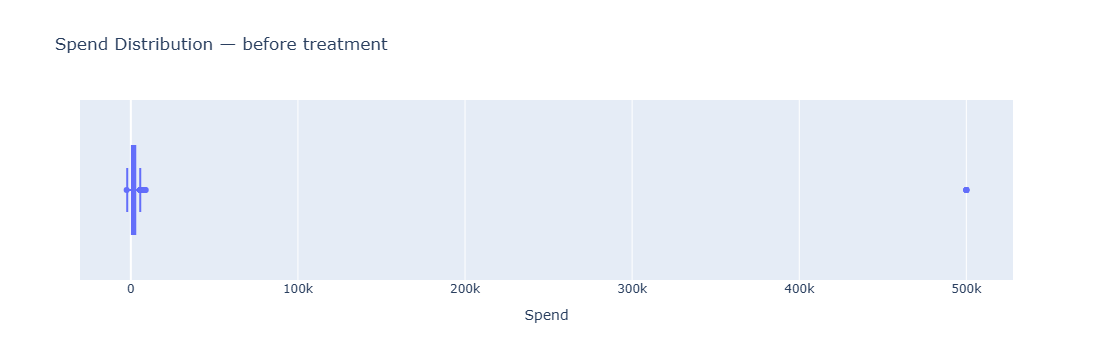

In [26]:
fig = px.box(df, x="Spend", title="Spend Distribution — before treatment")
fig.show()


In [27]:
Q1 = df["Spend"].quantile(0.25)
Q3 = df["Spend"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = max(0, Q1 - 3 * IQR)   # floor at 0 — spend can't be negative
upper_bound = Q3 + 3 * IQR

print(f"Lower bound (floored at 0): {lower_bound:.2f}")
print(f"Upper bound (3×IQR):        {upper_bound:.2f}")

outliers = df[(df["Spend"] < lower_bound) | (df["Spend"] > upper_bound)]
print(f"\nExtreme outliers detected: {len(outliers)}")
print(outliers[["Campaign_ID","Channel","Spend"]].sort_values("Spend"))


Lower bound (floored at 0): 0.00
Upper bound (3×IQR):        8613.14

Extreme outliers detected: 25
     Campaign_ID     Channel      Spend
1897   CMP-01898      TikTok   -2503.31
886    CMP-00887  Google Ads   -2162.50
1935   CMP-01936    Facebook   -1697.64
676    CMP-00677      TikTok   -1640.88
144    CMP-00145    Facebook   -1407.54
817    CMP-00818       Email   -1261.81
407    CMP-00408    Facebook   -1214.52
1317   CMP-01318      TikTok   -1197.93
1701   CMP-01702    Facebook   -1058.27
604    CMP-00605       Email    -942.80
1418   CMP-01419  Google Ads    -938.20
576    CMP-00577    Facebook    -821.80
924    CMP-00925    Facebook    -648.30
1559   CMP-01560  Google Ads    -647.64
1457   CMP-01458   Instagram    -551.19
1409   CMP-01410    Facebook    -386.43
1125   CMP-01126      TikTok    -122.80
1710   CMP-01711      TikTok     -65.19
1142   CMP-01143      TikTok     -20.05
1443   CMP-01444  Google Ads    8921.51
1718   CMP-01719       Email  500000.00
1754   CMP-01755    

In [28]:
# Winsorize — cap at bounds
df["Spend"] = df["Spend"].clip(lower=lower_bound, upper=upper_bound)

print("Spend after treatment:")
print(df["Spend"].describe())


Spend after treatment:
count    2000.000000
mean     1888.783353
std      1632.168508
min         0.000000
25%       649.412500
50%      1426.605000
75%      2640.345000
max      8613.142500
Name: Spend, dtype: float64


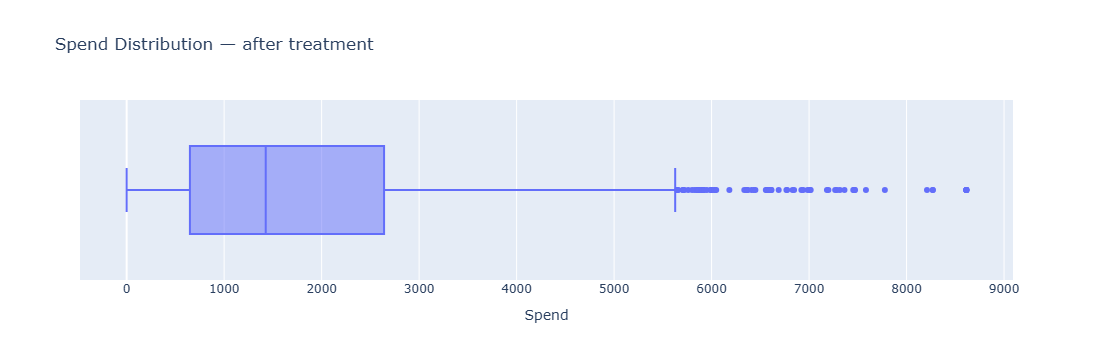

In [29]:
fig = px.box(df, x="Spend", title="Spend Distribution — after treatment")
fig.show()


### 9.2 Conversions

Conversions look healthy (max 943, 3×IQR upper bound is ~824 — a handful of outliers).
We retain these as valid high-performing campaigns rather than capping them.


In [30]:
Q1c = df["Conversions"].quantile(0.25)
Q3c = df["Conversions"].quantile(0.75)
IQRc = Q3c - Q1c
upper_c = Q3c + 3 * IQRc

conv_outliers = df[df["Conversions"] > upper_c]
print(f"Conversion outliers (>{upper_c:.0f}): {len(conv_outliers)} rows")
print(conv_outliers[["Campaign_ID","Channel","Conversions","Spend"]].sort_values("Conversions", ascending=False).head(10))


Conversion outliers (>733): 12 rows
     Campaign_ID     Channel  Conversions      Spend
1620   CMP-01621       Email        943.0  2702.4300
317    CMP-00318  Google Ads        803.0  5862.2700
504    CMP-00505  Google Ads        801.0  7363.1400
1002   CMP-01003   Instagram        794.0  5447.2700
1443   CMP-01444  Google Ads        790.0  8613.1425
1338   CMP-01339    Facebook        788.0  4581.0500
1707   CMP-01708       Email        786.0  6571.6600
347    CMP-00348  Google Ads        777.0  7583.1800
451    CMP-00452   Instagram        760.0  4458.4400
1493   CMP-01494      TikTok        760.0  7285.0400


**Decision:** Retain conversion outliers.
These are genuinely high-performing campaigns — removing or capping them would
bias any ROI or conversion rate analysis downward.


## Step 10: Final Check

Let's confirm the dataset is fully clean before signing off.


In [31]:
print("=" * 55)
print("  FINAL DATASET SUMMARY")
print("=" * 55)
print(f"  Original rows    : {rows_original:,}")
print(f"  Final rows       : {len(df):,}")
print(f"  Rows removed     : {rows_original - len(df):,}")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print(f"  Duplicates       : {df.duplicated().sum()}")
print()
print("--- Data Types ---")
print(df.dtypes)
print()
print("--- Numeric Summary ---")
df.describe()


  FINAL DATASET SUMMARY
  Original rows    : 2,020
  Final rows       : 2,000
  Rows removed     : 20
  Missing values   : 664
  Duplicates       : 0

--- Data Types ---
Campaign_ID                       object
Campaign_Name                     object
Start_Date                datetime64[ns]
End_Date                  datetime64[ns]
Channel                           object
Impressions                        int64
Clicks                             int64
Spend                            float64
Conversions                      float64
Active                             int64
Campaign_Tag                      object
Campaign_Duration_Days           float64
dtype: object

--- Numeric Summary ---


,Start_Date,End_Date,Impressions,Clicks,Spend,Conversions,Active,Campaign_Duration_Days
count,1668,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1668.000000
mean,2023-07-08 07:03:01.294964224,2023-07-21 14:04:33.600000,49850.026500,1501.237500,1888.783353,181.731500,0.591000,15.248801
min,2023-01-01 00:00:00,2022-12-31 00:00:00,1055.000000,11.000000,0.000000,0.000000,0.000000,1.000000
25%,2023-04-11 00:00:00,2023-04-22 00:00:00,24959.750000,650.750000,649.412500,76.000000,0.000000,8.000000
50%,2023-07-08 12:00:00,2023-07-20 00:00:00,50032.000000,1245.000000,1426.605000,142.000000,1.000000,15.000000
75%,2023-10-10 00:00:00,2023-10-22 00:00:00,74807.250000,2184.250000,2640.345000,240.250000,1.000000,23.000000
max,2024-01-01 00:00:00,2024-01-30 00:00:00,99875.000000,4812.000000,8613.142500,943.000000,1.000000,30.000000
std,NaN,NaN,28603.499545,1086.761057,1632.168508,152.706582,0.491772,8.582559


In [32]:
df.sample(15)

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Campaign_Tag,Campaign_Duration_Days
88,CMP-00089,Q4_Winter_CMP-00089,2023-09-29,2023-10-10,TikTok,87807,3125,1938.54,506.0,1,TI,11.0
710,CMP-00711,Q3_BlackFriday_CMP-00711,2023-10-06,2023-10-29,TikTok,24960,666,1093.91,71.0,1,TI,23.0
1246,CMP-01247,Q3_Winter_CMP-01247,2023-11-30,2023-12-22,Instagram,71835,2295,2910.80,450.0,1,IN,22.0
961,CMP-00962,Q2_Winter_CMP-00962,2023-12-02,2023-12-18,Facebook,47271,1360,1282.75,129.0,0,FA,16.0
705,CMP-00706,Q2_BlackFriday_CMP-00706,NaT,2023-01-09,Email,40298,1929,2250.74,124.0,1,EM,NaN
596,CMP-00597,Q1_Winter_CMP-00597,2023-06-13,2023-07-06,Google Ads,37208,949,1585.10,88.0,0,GO,23.0
617,CMP-00618,Q3_Launch_CMP-00618,NaT,2023-10-28,Facebook,70896,2184,1263.63,207.0,0,FA,NaN
746,CMP-00747,Q1_Winter_CMP-00747,2023-10-05,2023-10-27,Facebook,47427,780,396.32,63.0,1,FA,22.0
783,CMP-00784,Q2_BlackFriday_CMP-00784,2023-10-13,2023-10-23,Facebook,24833,281,293.40,27.0,0,FA,10.0
959,CMP-00960,Q1_Winter_CMP-00960,2023-02-18,2023-03-09,Instagram,35674,1031,695.63,134.0,0,IN,19.0


## Conclusion

Here's everything we fixed and why:

| Step | Problem | Fix Applied |
|------|---------|-------------|
| Column names | Spaces around `Campaign_ID`; duplicate `Clicks` column | Stripped whitespace; dropped empty duplicate |
| Dates | Mixed timestamp/date formats | Normalized to date-only with `dt.normalize()` |
| Spend | Mixed `$102.82` / `102.82` formats | Stripped `$`, converted to float |
| Active | 7 variations of yes/no | Mapped to clean 1/0 integer |
| Channel | 5 misspelled channel names | Standardized with explicit mapping |
| Campaign_Tag | `INVALID`, `XX`, `E-` bad tags | Re-derived from cleaned Channel (business logic) |
| Missing Channel | 101 nulls | Mode imputation |
| Missing Conversions | 200 nulls | Median imputation |
| Invalid date logic | 34 rows where End < Start | Swapped Start and End dates |
| Bonus column | — | Added `Campaign_Duration_Days` |
| Duplicates | 19 exact duplicate rows | Dropped, with before/after count |
| Spend outliers | Negative values + $500K spike | Winsorized at 3×IQR bounds (floored at 0) |
| Conversion outliers | High but valid performers | Retained with documented decision |

The dataset is now ready for exploratory analysis and modeling.
